In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import os


In [ ]:
# -----------------------------
# Step 1: Load Image
# -----------------------------
image = cv2.imread('input.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB
plt.imshow(image)
plt.title('Original Image')
plt.show()

error: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


In [6]:
import numpy as np
import cv2

with open('input.jpg', 'rb') as f:
    file_bytes = np.asarray(bytearray(f.read()), dtype=np.uint8)
    image = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)

if image is None:
    print("Still failed")
else:
    print("✅ Loaded using imdecode")

Still failed


In [2]:
# -----------------------------
# Step 1: Load Image
# -----------------------------
image = cv2.imread('input.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


error: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


In [20]:
import cv2

image = cv2.imread('input.jpg')

if image is None:
    print("Image NOT loaded. Check path.")
else:
    print("Image loaded successfully!")

Image NOT loaded. Check path.


In [21]:
import os

print(os.getcwd())  # shows current working directory

d:\College\Image Processing Mini Project


In [3]:
# -----------------------------
# Step 2: Downscale Image
# -----------------------------
scale_factor = 0.25  # Reduce to 25%
low_res = cv2.resize(image, None, fx=scale_factor, fy=scale_factor, interpolation=cv2.INTER_AREA)

In [5]:
# -----------------------------
# Step 3: Bicubic Upscaling
# -----------------------------
bicubic_upscaled = cv2.resize(low_res, (image.shape[1], image.shape[0]), interpolation=cv2.INTER_CUBIC)

In [8]:

# -----------------------------
# Step 4: Sharpening (NOVELTY)
# -----------------------------
kernel = np.array([[0, -1, 0],
                   [-1, 5,-1],
                   [0, -1, 0]])



sharpened = cv2.filter2D(bicubic_upscaled, -1, kernel)


In [9]:
# -----------------------------
# Step 5: Evaluation Metrics
# -----------------------------
psnr_bicubic = psnr(image, bicubic_upscaled)
psnr_sharp = psnr(image, sharpened)

ssim_bicubic = ssim(image, bicubic_upscaled, channel_axis=2)
ssim_sharp = ssim(image, sharpened, channel_axis=2)


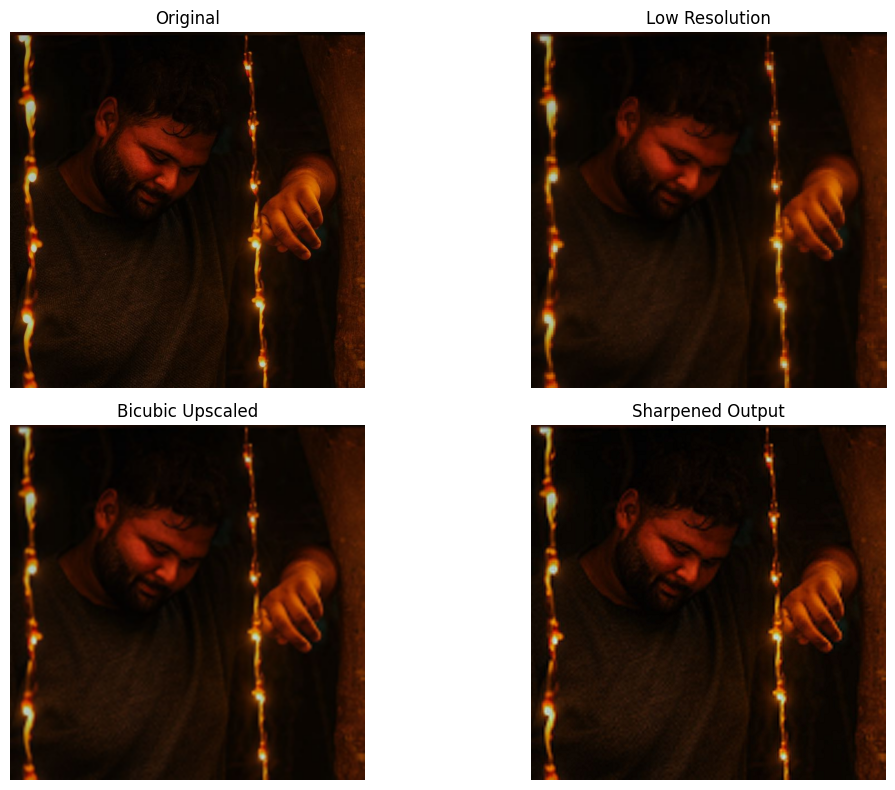

In [10]:

# -----------------------------
# Step 6: Display Results
# -----------------------------
titles = ['Original', 'Low Resolution', 'Bicubic Upscaled', 'Sharpened Output']
images = [image, low_res, bicubic_upscaled, sharpened]

plt.figure(figsize=(12, 8))

for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()